In [90]:
%pip install langchain langchain_groq langchain_community langgraph python_dotenv faiss_cpu pypdf

Note: you may need to restart the kernel to use updated packages.


In [91]:
%pip install langchain_huggingface sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [92]:
%pip install -U langchain langchain-community langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [93]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [94]:
load_dotenv()
import os

In [95]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [96]:
loader = PyPDFLoader("raa.pdf")

In [97]:
docs = loader.load()

incorrect startxref pointer(1)
parsing for Object Streams


In [98]:
print(type(docs))

<class 'list'>


In [99]:

print(len(docs))

2


In [100]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chuncks= splitter.split_documents(docs)

In [101]:
len(chuncks)

9

In [102]:
embeddings = HuggingFaceEmbeddings()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9910.31it/s]


In [103]:
vector_store = FAISS.from_documents(chuncks, embeddings)

In [104]:
vector_store

In [105]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':2})

In [106]:
retriever.invoke('what is ai')

[Document(id='562c5314-491c-4450-8c99-9f5edaba54fb', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-06-05T04:49:38+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-06-05T04:49:38+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'raa.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Artificial Intelligence (AI) - Detailed Report\nArtificial Intelligence (AI) is one of the most important technological developments of the modern\nera. It refers to the ability of computer systems to perform tasks that normally require human\nintelligence, such as learning, reasoning, decision-making, language understanding, and\nproblem-solving.\nThe concept of AI has existed for decades. Early researchers believed that machines could be\nprogrammed to imitate human thinking. Over time, advances in computing power, data storage, and\nalgorithms made it possible

In [107]:
from langchain_core.tools import tool

@tool
def rag_tool(query: str):
    """Search the vector database and return relevant documents."""

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }

In [108]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)


In [109]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [110]:
def chat_node(state: ChatState):
    messages = state.get("messages", [])
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [111]:
tool_node = ToolNode(tools)

In [112]:
graph = StateGraph(ChatState)

In [113]:
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

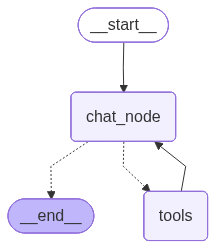

In [114]:
chatbot

In [115]:
resulta = chatbot.invoke({
    "messages": [
        HumanMessage(
            content=("using pdf explain about ai")
        )
    ]

})

In [116]:
resulta

{'messages': [HumanMessage(content='using pdf explain about ai', additional_kwargs={}, response_metadata={}, id='5d6b0c5d-467b-44a6-a969-5ddaf07533cf'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0akr7ag23', 'function': {'arguments': '{"query":"AI explanation in PDF format"}', 'name': 'rag_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 221, 'total_tokens': 240, 'completion_time': 0.054565346, 'completion_tokens_details': None, 'prompt_time': 0.012188477, 'prompt_tokens_details': None, 'queue_time': 0.050604144, 'total_time': 0.066753823}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9647-0eda-7331-86b7-156f9a948eaa-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'AI explanation in PDF format'}, 'id': '0akr7ag23', 'type': 'tool_call'}], invalid